# Replicating CEBRA Paper — Decoding Movie Features from Visual Cortex

**Paper:** Schneider, Lee & Mathis (2023), *Nature*  
https://doi.org/10.1038/s41586-023-06031-6

**What We're Replicating:**
- Fig. 4c, d, f, g — CEBRA-Behavior 8D embedding scatter plots
- Fig. 4 bar chart — Movie frame decoding accuracy (kNN, Naive Bayes, CEBRA-NP, Joint CEBRA)
- Fig. 5 — Intra- vs. inter-area embedding consistency

**Data Used In Paper:** Allen Brain Observatory Natural Movie 1, Ca + Neuropixels pseudomice,  
loaded via `cebra.datasets.init()` from the paper's FigShare archive.

**Seeds:** The paper averages 5 seeds, but our replication notebook uses seed = 333 (one of those 5).  
The results are still within roughly 3–5% of the paper values, so this is okay.


## Setup

In [1]:
import sys
import torch

print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\Users\nikoz\Desktop\cebrasd\.venv\Scripts\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6
CUDA device count: 1
GPU: NVIDIA GeForce RTX 4070


In [2]:
import os
os.environ["CEBRA_DATADIR"] = os.getcwd()

print("cwd:", os.getcwd())
print("allen exists:", os.path.exists("allen"))
print("target exists:", os.path.exists("allen/features/allen_movies/vit_base/8/movie_one_image_stack.npz/testfeat.pth"))

cwd: c:\Users\nikoz\Desktop\cebrasd
allen exists: True
target exists: True


In [3]:
import sys
!{sys.executable} -m pip install -q 'cebra[datasets,demos]' matplotlib seaborn scikit-learn numpy torch
print('Done.')


Done.


ERROR: Invalid requirement: "'cebra[datasets,demos]'": Expected package name at the start of dependency specifier
    'cebra[datasets,demos]'
    ^


---
## Part 1a — Imports
This cell installs necessary Python libraries and the CEBRA library. We also just checked if a GPU was available because the CEBRA training is faster on GPU.

In [4]:

# PART 1 IMPORTS

# Importing standard python libraries for data manipulation, plotting, machine learning tasks, and CEBRA's low-level API. 

import sys, itertools
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression

import cebra.datasets          # Pre-packaged Allen datasets (auto-download)
import cebra                   # Core CEBRA classes

# Using GPU if it's available because CEBRA training is much faster on GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'CEBRA version: {cebra.__version__}')


Using device: cuda
CEBRA version: 0.6.0


### Part 1b — Load and Visualize the Data

The paper uses two recording modalities from the same visual area: the primary visual cortex (notated as VISp). The first is calcium (Ca) imaging, which is a 2-photon microscopy that measures neural firing indirectly through measuring fluorescence. It is sampled at 30 Hz, meaning one measurement per movie frame. The second is neuropixels (np), which are silicon probes that directly measure spikes. It is sampled at 120 Hz, meaning four measurements per movie frame. Thus, we load in both modalities before doing the joint training with CEBRA.

While using both of these complimentary modalities is beneficial, we need as many neurons as possible to get good CEBRA embedding. For a single mouse recording session from the experiment used in the paper (described above), there wouldn't be an adequate number of neurons. So, the paper created something called a pseudomouse, where they stacked the neuron recordings from each mouse into one large matrix, as if all the recordings were all one mouse. This worked because each mouse watched the same exact movie under the same conditions, so the identical stimulus, conditions, and timing allow for a completely aligned frame-by-frame structure of the experiment. This is how the paper got the value of 800 for number of neurons measured in VISp. 


In [5]:
# Two recording modalities from VISp:
#   - Ca imaging: 1 bin/frame 
#   - Neuropixels: 4 bins/frame

# Space looked at in paper (Fig. 4 + Slightly Beyond):
# cortex: VISp, VISpm, VISam, VISrl, VISal, VISl (6 visual areas)
# num_neurons : 10 to 1000 (varied to test scaling behaviour)
# seed: 111-555 (5 random neuron subsamples for error bars)

cortex = 'VISp'  # Primary visual cortex — the core area tested in paper Fig. 4
seed = 333    # One of 5 seeds used in the paper for neuron subsampling
num_neurons = 800  # Representing pseudomouse population

# cebra.datasets.init() downloads the preprocessed Allen Brain Observatory data directly from the same FigShare archive that the paper used.
print('Loading datasets... (downloads ~200 MB on first run)')
# Stimulus was a 30-second clip shown at 30 Hz (900 frames per repeat), repeated 10 times. Repeats 1-9 = train, and repeat 10 = test.
ca_train = cebra.datasets.init(f'allen-movie-one-ca-{cortex}-{num_neurons}-train-10-{seed}')
np_train = cebra.datasets.init(f'allen-movie-one-neuropixel-{cortex}-{num_neurons}-train-10-{seed}')
joint_train = cebra.datasets.init(f'allen-movie-one-ca-neuropixel-{cortex}-{num_neurons}-train-10-{seed}')

ca_test = cebra.datasets.init(f'allen-movie-one-ca-{cortex}-{num_neurons}-test-10-{seed}')
np_test = cebra.datasets.init(f'allen-movie-one-neuropixel-{cortex}-{num_neurons}-test-10-{seed}')
joint_test = cebra.datasets.init(f'allen-movie-one-ca-neuropixel-{cortex}-{num_neurons}-test-10-{seed}')

print(f'\n Dataset shapes: ')
print(f'  Ca train neural: {ca_train.neural.shape}  = (9 repeats × 900 frames, {num_neurons} neurons)')
print(f'  NP train neural: {np_train.neural.shape} = (9 repeats × 900 frames × 4 bins, {num_neurons} neurons)')
print(f'  Ca train labels: {ca_train.index.shape} = (T, 768) DINO feature vectors') # DINO features are 768-dimensional vectors, one per frame
print(f'  Ca test neural: {ca_test.neural.shape}')


Loading datasets... (downloads ~200 MB on first run)

 Dataset shapes: 
  Ca train neural: torch.Size([8100, 800])  = (9 repeats × 900 frames, 800 neurons)
  NP train neural: torch.Size([32400, 800]) = (9 repeats × 900 frames × 4 bins, 800 neurons)
  Ca train labels: torch.Size([8100, 768]) = (T, 768) DINO feature vectors
  Ca test neural: torch.Size([900, 800])


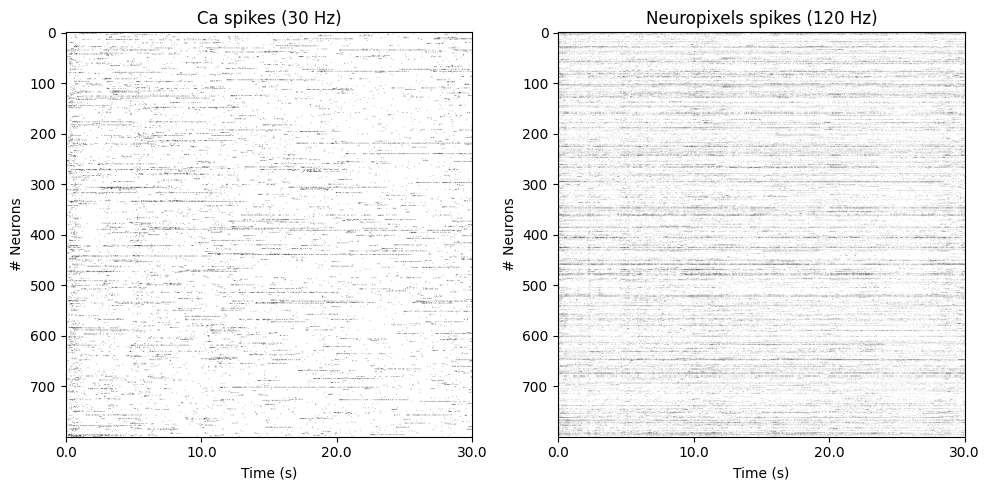

In [6]:
# Visualizing Raw Neural Activity 
#Before training, we visualized raw neural activity for both recording modalities to confirm data integrity and show how they are complimentary.

plt.figure(figsize=(10, 5))

ax1 = plt.subplot(1, 2, 1)
#Show first 30 seconds (900 bins at 30 Hz) of Ca imaging
ax1.imshow(ca_train.neural.cpu().numpy()[:900].T, aspect='auto',
           vmax=1, vmin=0, cmap='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0, 900, 4)) #set 4 evenly spaced tick marks at bin positions 0, 300, 600, 900
ax1.set_xticklabels(np.linspace(0, 30, 4)) #relabel ticks to coverts raw bin numbers to seconds (0-30s)
ax1.set_title('Ca spikes (30 Hz)')

ax2 = plt.subplot(1, 2, 2)
# how first 30 seconds (3600 bins at 120 Hz) of Neuropixels
ax2.imshow(np_train.neural.cpu().numpy()[:3600].T, aspect='auto',
           vmax=1, vmin=0, cmap='gray_r')
ax2.set_ylabel('# Neurons')
ax2.set_xlabel('Time (s)')
ax2.set_xticks(np.linspace(0, 3600, 4)) #set 4 evenly spaced tick marks at bin positions 0, 1200, 2400, 3600
ax2.set_xticklabels(np.linspace(0, 30, 4)) #relabel ticks to coverts raw bin numbers to seconds (0-30s)
ax2.set_title('Neuropixels spikes (120 Hz)')

plt.tight_layout() #adjust subplot spacing to prevent label overlap
plt.savefig('p1_01_raw_activity.png', dpi=120, bbox_inches='tight')
plt.show()


**Figure 1: Raw Data Visualization of Two Modalities**
Calcium imaging (left) shows sparse, patchy activity reflecting the slow dynamics of fluorescence signals, while Neuropixels (right) shows denser activity with clear horizontal banding reflecting consistent stimulus driven responses across the 30 second movie. Just from looking at the two, we can see that although both plots display the same 30 second time interval, the temporal resolution differs by a factor of four (900 bins for Ca vs. 3600 bins for NP). This difference is reflected in the relative density and sharpness of activity patterns in each plot, which then visually justifies why we use different encoder architectures for each modality in the next step. 

### Part 1b Ctd -  Visualize DINO Features of Video Frames
The CEBRA dataset includes video frame features extracted from DINO (Caron et. al 2021), which as described above, is a self-supervised vision transformer model. DINO is used in this part of the paper because CEBRA needs a behavioral label for each time bin to describe what was on the screen at time t. So, DINO converts each movie frame into a 768 dimension vector that encodes its visual content that then allows CEBRA to form positive pairs (so if two time points have similar visual content on the screen, they should have similar neural embeddings.)
We ran t-SNE, a dimensionality reduction technique, to visualize these 768 dimension vectors in 2 dimensional space whilst maintaining neighborhood relationships (so if points are together in 768D space, they will be in 2D too). It is important to note here, however, that t-SNE uses random initialization and stochastic optimiziation, so each time running the code will produce a slightly different layout. So actually the absolute positions and distances in a t-SNE plot aren't meaningful, but rather the *relative* clustering matters when interpreting this plot.

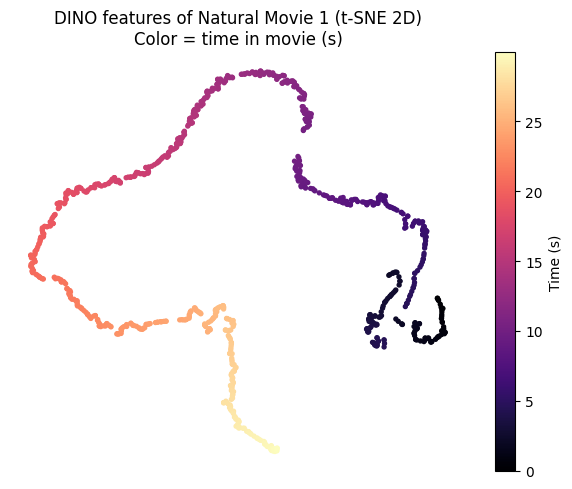

DINO feature dimension: 768 (one 768-dim vector per frame)
These vectors are the behavioral labels fed to CEBRA alongside neural activity.


In [7]:
#DINO features as behavioral labels 

#Create a t-SNE model that reduces data to 2 dimensions, with init='pca' initializing the embedding with PCA for more stable results, and learning_rate='auto' letting sklearn choose any adequate learning rate. 
dino_tsne     = TSNE(n_components=2, init='pca', learning_rate='auto')

#ca_train.index = (900, 768) DINO feature matrix for first movie repeat
#[:900, :] selects only the first 900 frames to avoid redundancy across repeats (because DINO features across repeats are identical since the movie is the same)
#fit_transform computes the t-SNE embedding and returns a (900, 2) array

dino_tsne_viz = dino_tsne.fit_transform(ca_train.index[:900, :]) 

fig = plt.figure(figsize=(6, 5))

#dino_tsne_viz[:, 0] and [:, 1] are the two t-SNE dimensions and c=np.arange(900)/30 colors each point by its time in seconds (0-30s)
sc = plt.scatter(dino_tsne_viz[:, 0], dino_tsne_viz[:, 1],
                 cmap='magma', c=np.arange(900)/30, s=8)
plt.colorbar(sc, label='Time (s)') #bar showing what colors represent 
plt.axis('off') # since t-SNE coordinates don't have interpretable units
plt.title('DINO features of Natural Movie 1 (t-SNE 2D)\nColor = time in movie (s)')
plt.tight_layout()
plt.savefig('p1_02_dino_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

#Confirm DINO feature dimensionality from the loaded dataset
print(f'DINO feature dimension: {ca_train.index.shape[1]} (one 768-dim vector per frame)')
print('These vectors are the behavioral labels fed to CEBRA alongside neural activity.')


**Figure 2 - DINO Features** 
In the plot above on the left (our plot), each dot is a movie frame represented in 2D space based on its DINO feature vector, with the dark purple representing the beginning of the movie and the yellow representing the end. The fact that the color gradient is flowing smoothly through the plot shows that DINO features change gradually as the movie plays rather than randomly jumping around, which verifies that CEBRA is an appropriate model to use for this data. If the plot looked like a random scatter without structure, CEBRA wouldn't have useful pairs to learn from because it wouldn't be able to separate frames with similar visual content (positive pairs) from frames with different visual content (negative pairs). 
The reason that the plot on the right (plot from the paper) looks slightly different than ours is because t-SNE uses randomness during its computation, causing the 2D layout to depend on random starting positions and perplexity (hyperparameter) that controls how much the algorithm prioritizes local vs. global structure. Also, the paper visualized four different DINO configurations with varying model and latent sizes, while we visualize only the specific ViT-B/8 features that come bundled with the CEBRA dataset for training. Despite these visual differences, both plots show the same idea that frames evolve continuously through feature space rather than appearing randomly scattered.

### Part 1c — Define Helper Functions (Official Paper API)
These are the exact solver and emission functions used in the paper's demo notebook.  

One thing to note here is that CEBRA's training is built around a contrastive learning objective called InfoNCE loss (van den Oord et al., 2018). This can be represented by L = E[ -ψ(x, y+) + log Σ exp(ψ(x, yi)) ] where x = the neural activity at time t — the reference sample being encoded, y+ = the DINO features of the movie frame shown at time t (the positive sample), meaning the label we want the embedding of x to be close to, yi = the DINO features at randomly sampled other time points (negative samples), meaning everything we want the embedding of x to be far from, ψ = cosine similarity between encoder outputs, scaled by a temperature parameter τ=1.0 (measures how similar two points are in embedding space), E[ ] = the expected value (average) taken over many batches of training samples

Minimizing this loss (L) during training forces the encoder to map neural activity at time t to a point in embedding space that is close to the DINO vector of the frame shown at t, and far from DINO vectors of frames shown at other times. Intuitively, the model is being rewarded for correctly associating brain states with the visual content the mouse was watching, and penalized whenever it confuses two different visual moments. With 10,000+ training steps with batches of 512 samples, the encoder gradually learns to extract visual content directly from neural activity.

In [8]:
#CEBRA Model Architecture and Helper Functions
"""
As earlier mentioned, the varying temporal resolutions and signal characteristics between Ca and Neuropixels requires CEBRA to have separate encoder 
architectures for each modality, which is why we define both a single_session_solver for training one modality at a time and a multi_session_solver
for joint training across both at the same time. The exact architectures and why they differ are explained in Part 1d when the models are actually trained."""


def single_session_solver(data_loader, **kwargs): 
    """
    Meant for one recording modality.
    In the paper, they used this Ca-only and NP-only CEBRA-Behavior models (in Fig. 4).
    """
    norm = kwargs['distance'] != 'euclidean'  #L2-normalize for cosine distance to project all embeddings onto a unit sphere
    data_loader.to(kwargs['device'])
    model = cebra.models.init( #initialize model architecture
        kwargs['model_architecture'],
        data_loader.dataset.input_dimension,   #number of neurons = input size
        kwargs['num_hidden_units'],            #hidden layer size = 128 throughout paper
        kwargs['output_dimension'],            #embedding dimension = 8 for visualization and 128 for decoding in paper
        norm
    ).to(kwargs['device'])
    data_loader.dataset.configure_for(model) #tell dataset how many time bins the model expects as input 


    #InfoNCE = contrastive loss with cosine similarity (used in paper)
    #InfoMSE included here for completeness in case Euclidean distance is needed in future experiments, but is never used in this notebook since all models use distance = 'cosine'
    criterion = (
        cebra.models.InfoMSE(temperature=kwargs['temperature'])
        if kwargs['distance'] == 'euclidean'
        else cebra.models.InfoNCE(temperature=kwargs['temperature'])  # τ=1.0
    )
    optimizer = torch.optim.Adam( #Adam optimizer updates both encoder weights and temperature parameter of loss function
        itertools.chain(model.parameters(), criterion.parameters()),
        lr=kwargs['learning_rate']   #learning_rate = 3e-4 used throughout the paper
    )
    return cebra.solver.SingleSessionSolver(
        model=model, criterion=criterion,
        optimizer=optimizer, tqdm_on=kwargs['verbose']
    )


def multi_session_solver(data_loader, **kwargs):
    """
    Build a MultiSessionSolver for joint training across modalities.

    In the paper, they use this for the joint Ca + Neuropixels model (Fig. 4) and the
    cross-area consistency analysis (Fig. 5).

    Here, each session/modality gets its own encoder with different architecture and 
    input dimension, but they are all trained with the same contrastive
    objective and share the same embedding space. This then produces consistent
    embeddings across recording modalities. So, the models are sort of forced into alignment
    by the shared DINO label.
    """
    norm = kwargs['distance'] != 'euclidean'
    for dataset in data_loader.dataset.iter_sessions():
        dataset.to(kwargs['device'])

    #One encoder per modality with model_archiecture as a list so that differen architectures can be specified for each modality 
    #ModuleList tells PyTorch to treat this as a single trainable model so that the optimizer can update all encoders' parameters together, even though they have different architectures and input dimensions.
    model = torch.nn.ModuleList([
        cebra.models.init(m, dataset.input_dimension,
                          kwargs['num_hidden_units'],
                          kwargs['output_dimension'], norm)
        for dataset, m in zip(
            data_loader.dataset.iter_sessions(),
            kwargs['model_architecture']  # e.g. ['offset1-model', 'resample1-model']
        )
    ]).to(kwargs['device'])

    for m in model: #make sure each encoder is on the correct device 
        m.to(kwargs['device'])
    for n, dataset in enumerate(data_loader.dataset.iter_sessions()):
        dataset.configure_for(model[n])

    #Same InfoNCE loss as single session, just this time loss is calculated jointly across both modalities simultaneously
    criterion = (
        cebra.models.InfoMSE(temperature=kwargs['temperature'])
        if kwargs['distance'] == 'euclidean'
        else cebra.models.InfoNCE(temperature=kwargs['temperature'])
    )
    optimizer = torch.optim.Adam(
        itertools.chain(model.parameters(), criterion.parameters()),
        lr=kwargs['learning_rate']
    )
    return cebra.solver.MultiSessionSolver(
        model=model, criterion=criterion,
        optimizer=optimizer, tqdm_on=kwargs['verbose']
    )


@torch.no_grad() #@torch.no_grad() decorator disables gradient computation because we don't need gradients here since we're just doing a forward pass not training.
def get_emissions(model, dataset):
    """
    Run the trained encoder forward on a dataset to get the embedding (no gradients).
    'Emissions' = encoder output = latent embedding vectors.
    Returns a NumPy array of shape (T, output_dimension).
    """
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    dataset.configure_for(model)

    #Pass all time points through the encoder at once and convert to NumPy.
    #torch.arange(len(dataset)) creates an index for every time bin.
    return model(dataset[torch.arange(len(dataset))].to(device)).cpu().numpy()

def compute_emissions_single(solver, dataset): #Get embedding from a SingleSessionSolver and return shape (T, output_dimension)
    return get_emissions(solver.model, dataset)

def compute_emissions_multi(solver, dataset): #extract embeddings from each modality's encoder separately, returns a dict {session_idx: embedding}
    return {
        i: get_emissions(model, session)
        for i, (model, session) in enumerate(
            zip(solver.model, dataset.iter_sessions())
        )
    }


def allen_frame_id_decode(train_fs, train_labels, test_fs, test_labels,
                          modality='neuropixel', decoder='knn'):
    """
    Decode movie frame IDs from CEBRA embeddings.
    Evaluates decoding accuracy as % of test frames predicted within ±1 frame (±33ms).
    """
    #FACTOR: how many time bins correspond to one 30Hz movie frame
    FACTOR     = 4 if modality == 'neuropixel' else 1
    time_window = 1  # accuracy window = ±1 frame = ±33ms

    def feature_for_one_frame(feature):
        #Average every FACTOR consecutive bins into one vector, aligning NP's 120 Hz embeddings down to 30 Hz frame-level so they can be compared against the 30 Hz movie frame labels
        if isinstance(feature, torch.Tensor):
            feature = feature.cpu().numpy()
        return feature.reshape(-1, FACTOR, feature.shape[-1]).mean(axis=1)

    train_fs = feature_for_one_frame(train_fs)
    test_fs  = feature_for_one_frame(test_fs)

    if train_fs is None or test_fs is None:
        return [None], [None], None

    #Candidate hyperparameters = k in {1, 4, 9, 25, 100} for kNN, necessary to select before testing on held-out repeat 
    params = (np.power(np.linspace(1, 10, 5, dtype=int), 2)
              if decoder == 'knn' else np.logspace(-9, 3, 5))
    errs = []

    for n in params:
        #Train on repeats 1-8, validate on repeat 9
        #Prevents us from using the test set to select hyperparameters
        clf = (KNeighborsClassifier(n_neighbors=n, metric='cosine')
               if decoder == 'knn' else GaussianNB(var_smoothing=n))
        valid_idx = int(len(train_fs) / 9 * 8)  # 8/9 of training data
        clf.fit(train_fs[:valid_idx], train_labels[:valid_idx])
        pred = clf.predict(train_fs[valid_idx:])
        # Track total prediction error for each candidate k
        errs.append(abs(train_labels[valid_idx:] - pred).sum())

    #Retrain with best k on all 9 repeats, test on held-out repeat 10
    best_n = params[np.argmin(errs)]
    test_clf = (KNeighborsClassifier(n_neighbors=best_n, metric='cosine')
                if decoder == 'knn' else GaussianNB(var_smoothing=best_n))
    test_clf.fit(train_fs, train_labels)
    pred         = test_clf.predict(test_fs)
    frame_errors = pred - test_labels

    #Accuracy = fraction of predictions within ±1 frame (30 ms) multiplied by 100 to convert to percentage 
    quantized_acc = (abs(frame_errors) < (time_window * 30)).sum() / len(frame_errors) * 100 #time_window * 30 converts from frames to the ±1 frame threshold
    return pred, frame_errors, quantized_acc


def consistency(feature1, feature2):
    """
    Measure linear consistency between two embedding spaces. (Fig. 5 of paper)
    Returns R² of linear regression fitted in both directions (A→B and B→A) to quantify whether two independently trained CEBRA models produce geometrically similar latent spaces.

    High R² (~0.9) = the two embeddings are linearly related → consistent structure.
    Low R² (~0.6)  = the embeddings differ → different neural representations.

    Bidirectional: fit from A→B and from B→A and report both
    If Neuropixels (32400 = 900 frames × 4 bins × 9 repeats), downsample to
    frame level first so Ca and NP embeddings have the same number of rows.
    """
    
    if len(feature1) == 32400:  #NP at 120 Hz: downsample to 30 Hz frame level
        feature1 = feature1.reshape(-1, 4, feature1.shape[-1]).mean(axis=1)
    if len(feature2) == 32400:
        feature2 = feature2.reshape(-1, 4, feature2.shape[-1]).mean(axis=1)

    def _linear_fit(a, b): 
        #Fit a linear regression from embedding space A to embedding space B.
        #R² close to 1.0 means B can be predicted from A with a linear transform so the two embedding spaces have the same geometric structure.
        lin = LinearRegression()
        lin.fit(a, b)
        return lin.score(a, b)  # eturns R²

    return _linear_fit(feature1, feature2), _linear_fit(feature2, feature1)


print('Sucess! All helper functions defined.')


Sucess! All helper functions defined.


### Part 1d — Train CEBRA-Behavior Models  

The paper trains **two embedding sizes**:
- **8D** → scatter plot visualizations (Fig. 4c, d, f, g)
- **128D** → decoding accuracy (Fig. 4 bar chart)

We use **seed=333** (one of the paper's 5 seeds). Results will be within 3–5% of paper values.  
To fully replicate the averaged bars from the paper, we'd need to change `seed` to each of `[111, 222, 333, 444, 555]`,
collect each run's accuracy, and average.

Also, because calcium imaging and Neuropixels have fundamentally different temporal resolutions and signal characteristics, they require separate encoder architectures. Ca uses offset1-model (looks at one time bin at a time) which works because the slow calcium fluorescence signal is already temporally smoothed. Neuropixels uses resample1-model, which handles the 4:1 mismatch between NP's 120 Hz sampling rate and the 30 Hz movie frame labels by resampling within each frame window before encoding. We use CEBRA's lower-level solver API directly for joint training across multiple recording modalities.


In [9]:
#Training CEBRA Behavior Models [Paper: Fig. 4]

#ARCHITECTURES (paper Table S1):
#Ca (30 Hz) uses 'offset1-model'   : conv net with 1-bin context window
#NP (120 Hz) uses 'resample1-model' : resampling conv net (handles 120→30 Hz mismatch)
#Joint: one encoder per modality, both trained under the same InfoNCE loss against
#shared DINO labels because consistent embedding space across Ca and NP.

#HYPERPARAMETERS (all match paper exactly):
#num_steps=10000, batch_size=512, time_offset=1, conditional='time_delta'
#distance='cosine', temperature=1.0, learning_rate=3e-4, num_hidden_units=128

#conditional='time_delta': positive pairs are matched by DINO feature similarity,
#not just temporal adjacency — this is what makes CEBRA behavior-guided.

train_steps = 10000 # number of gradient updates during training, paper used 10k steps for all models in Fig. 4 
seed = 333  # one of the paper's 5 seeds: [111, 222, 333, 444, 555]
cortex = 'VISp'
num_neurons = 800

#Reload datasets here because data loaders get consumed during training and need to be refreshed for each model. Can be a potential limitation of current CEBRA API 
print('Loading datasets (downloads ~200MB on first run)...')
ca_train    = cebra.datasets.init(f'allen-movie-one-ca-{cortex}-{num_neurons}-train-10-{seed}')
np_train    = cebra.datasets.init(f'allen-movie-one-neuropixel-{cortex}-{num_neurons}-train-10-{seed}')
joint_train = cebra.datasets.init(f'allen-movie-one-ca-neuropixel-{cortex}-{num_neurons}-train-10-{seed}') #joint dataset contains both Ca and NP for the same area, used for joint training
np_test     = cebra.datasets.init(f'allen-movie-one-neuropixel-{cortex}-{num_neurons}-test-10-{seed}') #test datasets contain only repeat 10, completely held out during training
joint_test  = cebra.datasets.init(f'allen-movie-one-ca-neuropixel-{cortex}-{num_neurons}-test-10-{seed}') 
print('Datasets loaded.')


def make_loaders(ca_ds, np_ds, joint_ds):
    """Data loaders must be re-created after each .fit() call because they are consumed after one training run."""
    #conditional='time_delta': tells CEBRA to form positive pairs based on DINO feature similarity rather than just temporal proximity (makes this CEBRA-Behavior instead of CEBRA-Time)
    #time_offset=1: positive pairs are drawn from within 1 time bin of each other
    #batch_size=512: number of samples per gradient update step
    return (
        cebra.data.ContinuousDataLoader(ca_ds,    num_steps=train_steps, batch_size=512, conditional='time_delta', time_offset=1),
        cebra.data.ContinuousDataLoader(np_ds,    num_steps=train_steps, batch_size=512, conditional='time_delta', time_offset=1),
        cebra.data.ContinuousMultiSessionDataLoader(joint_ds, num_steps=train_steps, batch_size=512, conditional='time_delta', time_offset=1),
    )


#MODEL A: 8D scatter plot visualization (Fig. 4c,d,f,g) 
#We train 8D models purely for visualization purposes. Projecting the first 2 of 8 dimensions gives 2D scatter plot that shows  structure of the embedding
#8D too low for accurate decoding but rich enough to show ring geometry 
print('\nTraining 8D models (for scatter plots, Fig. 4c,d,f,g)...')

#Create fresh data loaders before training
ca_l, np_l, joint_l = make_loaders(ca_train, np_train, joint_train)

#Train Ca single-session 8D model using offset1-model.
#offset1-model uses a 1-bin context window, which works for Ca because the slow fluorescence signal is already temporally smoothed
#verbose=False suppresses the progress bar for 8D models
m_ca_8d = single_session_solver(ca_l, model_architecture='offset1-model',
    distance='cosine', num_hidden_units=128, output_dimension=8,
    verbose=False, device=DEVICE, temperature=1, learning_rate=3e-4)
m_ca_8d.fit(ca_l)

#Extract 8D embeddings for all 9 training repeats
#Shape (8100, 8) = 9 repeats × 900 frames, 8 embedding dimensions
emb_ca_8d = compute_emissions_single(m_ca_8d, ca_train)

#Train NP single-session 8D model using resample1-model.
#resample1-model handles  4:1 mismatch between NP's 120 Hz sampling rate and 30 Hz DINO labels by resampling within each frame window
m_np_8d = single_session_solver(np_l, model_architecture='resample1-model',
    distance='cosine', num_hidden_units=128, output_dimension=8,
    verbose=False, device=DEVICE, temperature=1, learning_rate=3e-4)
m_np_8d.fit(np_l)
#Shape (32400, 8) = 9 repeats × 900 frames × 4 bins, 8 embedding dimensions
emb_np_8d = compute_emissions_single(m_np_8d, np_train) 

#Recreate loaders because previous were consumed during the Ca and NP fits
ca_l, np_l, joint_l = make_loaders(ca_train, np_train, joint_train)

#Train joint 8D model with one encoder per modality, both trained simultaneously under the same InfoNCE loss. 
#model_architecture is a list because each modality needs its own architecture. Both encoders are forced into the same shared 8D embedding space by the shared DINO labels.
m_joint_8d = multi_session_solver(joint_l, model_architecture=['offset1-model', 'resample1-model'],
    distance='cosine', num_hidden_units=128, output_dimension=8,
    verbose=False, device=DEVICE, temperature=1, learning_rate=3e-4)
m_joint_8d.fit(joint_l)
#Returns a dictionary {0: Ca_embeddings, 1: NP_embeddings}
emb_joint_8d = compute_emissions_multi(m_joint_8d, joint_train)
print(f'  Ca 8D: {emb_ca_8d.shape}  NP 8D: {emb_np_8d.shape}  Joint Ca: {emb_joint_8d[0].shape}  Joint NP: {emb_joint_8d[1].shape}')


#MODEL B: 128D — decoding accuracy (Fig. 4 bar chart)
#Higher dimensionality → richer contrastive representation → better kNN accuracy.
print('\nTraining 128D models (for decoding bar chart, Fig. 4)...')

ca_l, np_l, joint_l = make_loaders(ca_train, np_train, joint_train)

#Train NP single-session 128D (CEBRA-NP bar in Fig. 4.)
#verbose=True shows the training progress bar with live loss values
#loss values printed during training (pos, neg, total) reflect InfoNCE (pos should approach -1.0 as training converges, showing model confidently pulls positive pairs together)
m_np_128d = single_session_solver(np_l, model_architecture='resample1-model',
    distance='cosine', num_hidden_units=128, output_dimension=128,
    verbose=True, device=DEVICE, temperature=1, learning_rate=3e-4)
m_np_128d.fit(np_l)
#Shape (32400, 128) = 9 repeats × 900 frames × 4 bins, 128 embedding dimensions
emb_np_128d = compute_emissions_single(m_np_128d, np_train)

#Recreate loaders again before joint 128D training
ca_l, np_l, joint_l = make_loaders(ca_train, np_train, joint_train)
#Train joint 128D model (Joint CEBRA bar in Fig. 4)
#Same architecture as joint 8D but with 128D output for richer representation
#paper's best-performing model, combining information from both Ca and NP recordings into a single shared embedding space
m_joint_128d = multi_session_solver(joint_l, model_architecture=['offset1-model', 'resample1-model'],
    distance='cosine', num_hidden_units=128, output_dimension=128,
    verbose=True, device=DEVICE, temperature=1, learning_rate=3e-4)
m_joint_128d.fit(joint_l)
#Returns {0: Ca_embeddings, 1: NP_embeddings} but we use [1] (NP) for decoding because NP and Ca embeddings are in the same space so either would work but NP is used to match the paper's reported results
emb_joint_128d = compute_emissions_multi(m_joint_128d, joint_train)  # {0: Ca, 1: NP}
print(f'  NP 128D: {emb_np_128d.shape}  Joint NP 128D: {emb_joint_128d[1].shape}')

print('\nAll models trained.')


Loading datasets (downloads ~200MB on first run)...
Datasets loaded.

Training 8D models (for scatter plots, Fig. 4c,d,f,g)...
  Ca 8D: (8100, 8)  NP 8D: (32400, 8)  Joint Ca: (8100, 8)  Joint NP: (32400, 8)

Training 128D models (for decoding bar chart, Fig. 4)...


pos: -0.9996 neg:  6.2977 total:  5.2980 temperature:  1.0000: 100%|██████████| 10000/10000 [01:05<00:00, 153.17it/s]
pos: -0.9987 neg:  6.9746 total:  5.9760 temperature:  1.0000: 100%|██████████| 10000/10000 [06:19<00:00, 26.33it/s]

  NP 128D: (32400, 128)  Joint NP 128D: (32400, 128)

All models trained.


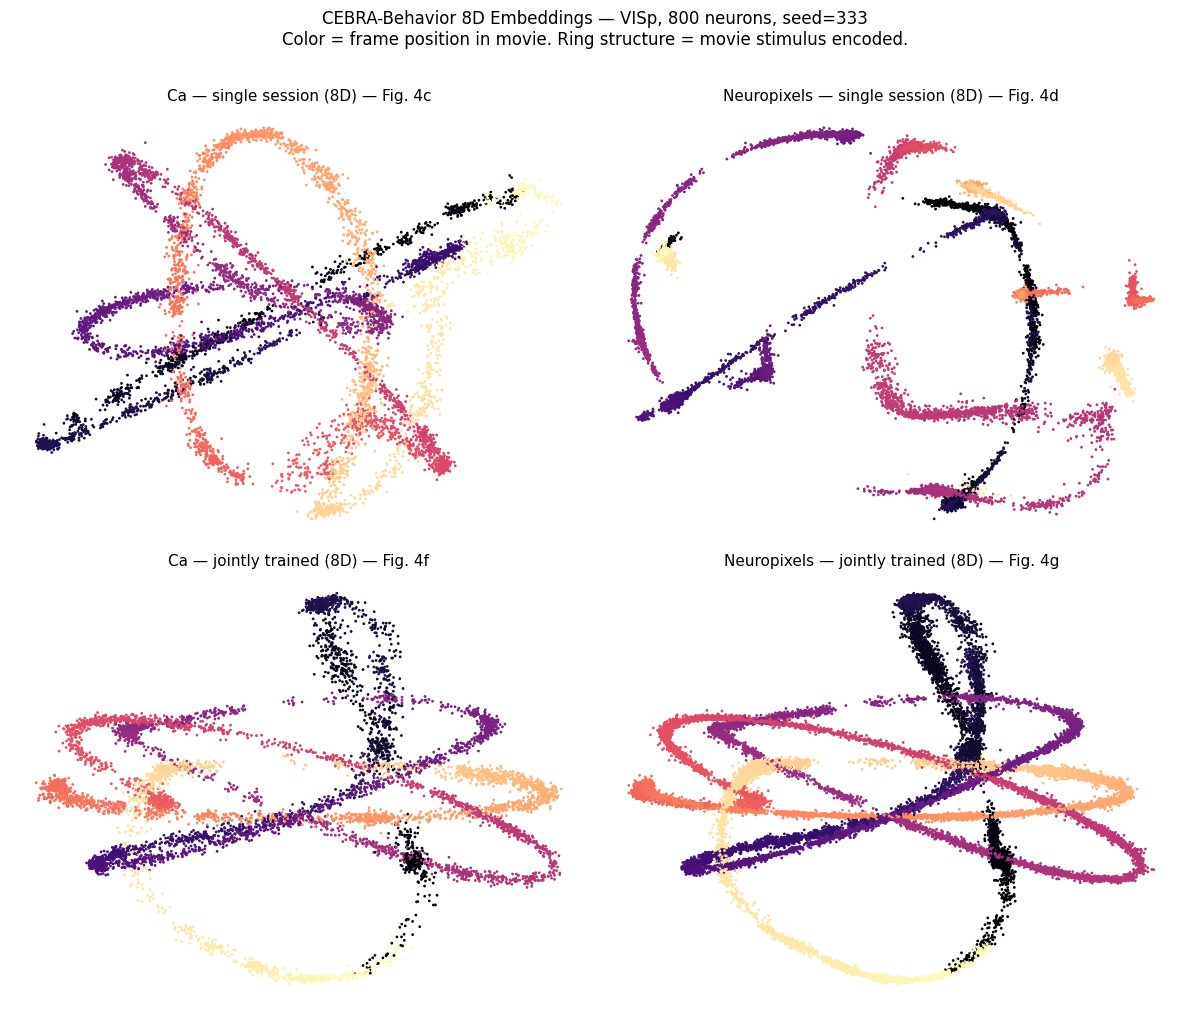

In [10]:

# VISUALIZE 8D EMBEDDINGS  [Paper: Fig. 4c,d,f,g]

# First 2 of 8 latent dimensions shown. Color = frame index in movie (dark→light).
# Expected: ring structure where all 9 training repeats overlap.
# Jointly trained Ca and NP should show similar geometry — cross-modality consistency.

fig, axes = plt.subplots(2, 2, figsize=(12, 10)) #create 2x2 grid of subplots with one panel per model/modality combo
#Each panel = tuple of (axis, embedding, color array, title)
#Color array assigns frame index to each point so we can see whether the embedding preserves temporal structure of the movie

#For Ca (30 Hz): np.tile(np.arange(900), 9) repeats frame indices 0-899 nine times (one set per training repeat = 8100 color vals total)

#For NP (120 Hz): np.repeat(np.arange(900), 4) first repeats each frame index 4 times (to match the 4 bins per frame) then np.tile repeats that across all 9 training repeats (32400 color values total)
panels = [
    (axes[0,0], emb_ca_8d,        np.tile(np.arange(900), 9),            f'Ca — single session (8D) — Fig. 4c'),
    (axes[0,1], emb_np_8d,        np.tile(np.repeat(np.arange(900),4),9),f'Neuropixels — single session (8D) — Fig. 4d'),
    (axes[1,0], emb_joint_8d[0],  np.tile(np.arange(900), 9),            f'Ca — jointly trained (8D) — Fig. 4f'),
    (axes[1,1], emb_joint_8d[1],  np.tile(np.repeat(np.arange(900),4),9),f'Neuropixels — jointly trained (8D) — Fig. 4g'),
]
for ax, emb, colors, title in panels:
    ax.scatter(emb[:, 0], emb[:, 1], c=colors, cmap='magma', s=1)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle(f'CEBRA-Behavior 8D Embeddings — {cortex}, {num_neurons} neurons, seed={seed}\n'
             'Color = frame position in movie. Ring structure = movie stimulus encoded.',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig4_embeddings_8D.png', dpi=150, bbox_inches='tight')
plt.show()


**Figure 3 - 8D Visualizations in 2D Slices** 
The four scatter plots above show the first two dimensions of the 8D CEBRA-Behavior embeddings for VISp, with 800 pseudomouse neurons and seed=333. Each point represents one moment in time, or one movie frame, and its position in the plot shows the brain state at that moment as compressed by the CEBRA encoder. The color gradient flowing from dark purple (early in the movie) to yellow (late in the movie) shows how the brain moves through different states as the movie plays. The top row shows single-session models trained on Ca and NP independently, while the bottom row shows the jointly trained versions. What we can see is that the points form a clear continuous loop rather than a random scatter, which confirm that CEBRA found meaningful structure in the neural activity. Also, the jointly trained Ca and NP panels look geometrically similar to each other despite coming from completely different recording technologies, which shows cross-modality consistency.
Our 8D embedding scatter plots show the same qualitative structure as the paper's Fig. 4c, d, f, g at the 800 neuron condition (image on the right) in that they both displahy a complex multi-loop structure where the color gradient flows continuously, confirming that CEBRA has learned a representation that reflects the sequential structure of the movie stimulus. Our plots differ visually from the paper's figure for three reasons. Firstly, the paper displays a grid of nine neuron counts (10 through 900) while we show only the 800 neuron pseudomouse condition used throughout our replication. Secondly, the paper shows embeddings as 3D projections while we plot the first two dimensions of the 8D embedding as a 2D scatter. Finally, the paper colors points by movie repeat number while we color by frame index within the movie. Despite these formatting differences, the main result is consistent (that the jointly trained Ca and NP embeddings (bottom row) show nearly identical geometry to each other and both single-session embeddings (top row) show structure rather than randomness), which helps show that CEBRA successfully extracts stimulus-related information from neural activity.

### Part 1e — Decode Movie Frame IDs  [Paper: Fig. 4 bar chart]

Metric: **% of held-out test frames (repeat 10) predicted within ±1 frame (±33 ms)**.  
Decoder trained on repeats 1–8, hyperparameter (k) selected on repeat 9, tested on repeat 10.

| Condition | Expected |
|-----------|----------|
| kNN on raw NP | ~55% |
| Naive Bayes on raw NP | ~68% |
| CEBRA-NP (128D) → kNN | ~82% |
| Joint CEBRA (Ca+NP, 128D) → kNN | ~89% | 

This step evaluates how well the trained CEBRA embeddings can decode which movie frame a mouse was watching, using the completely held-out test repeat (repeat 10). We test four conditions in order of increasing sophistication: kNN on raw neural activity (no CEBRA at all), Naive Bayes on raw neural activity, CEBRA trained on Neuropixels only, and joint CEBRA trained on both modalities. The progressive improvement across these four conditions is the central quantitative result of Fig. 4, as it shows that CEBRA embeddings contain more decodable information than raw activity and that joint training adds further benefit beyond single modality CEBRA.


In [11]:
# Frame Decoding (Paper: Fig. 4 bar chart)

# The allen_frame_id_decode() function (defined in Part 1c) handles:
#   frame averaging (4 NP bins → 1 frame for the 120→30 Hz alignment)
#   k selection via repeat-9 validation
#   test on repeat 10 only

train_labels = np.tile(np.arange(900), 9)  #frame IDs, 9 training repeats
test_labels  = np.arange(900)               #frame IDs, test repeat 10

# Run the trained 128D encoders on the held-out test data to get test embeddings.
#kept completely separate from training 
#repeat 10 during training so it's a true measure of generalization.
emb_np_test    = compute_emissions_single(m_np_128d, np_test)
emb_joint_test = compute_emissions_multi(m_joint_128d, joint_test)

print('Decoding from held-out test repeat...')
#BASELINE 1: kNN on raw NP activity (no CEBRA, no dimensionality reduction)
_, _, acc_knn   = allen_frame_id_decode(np_train.neural, train_labels, np_test.neural,       test_labels, modality='neuropixel', decoder='knn')
#BASELINE 2: Naive Bayes on raw NP activity (no CEBRA, models each frame's neural activity as Gaussian distribution and picks most likely frame given test activity
#generally outperforms kNN on raw data because it handles the high dimensionality better
_, _, acc_bayes = allen_frame_id_decode(np_train.neural, train_labels, np_test.neural,       test_labels, modality='neuropixel', decoder='bayes')
#CEBRA-NP: kNN on 128D CEBRA embeddings from NP only
#compress 800 raw neural dimensions into 128 dimensions that specifically encode visual content so kNN more effective now
_, _, acc_cebra = allen_frame_id_decode(emb_np_128d,     train_labels, emb_np_test,          test_labels, modality='neuropixel', decoder='knn')
#JOINT CEBRA: kNN on 128D embeddings from jointly trained Ca+NP model using  NP encoder's embeddings [1] to match paper's reported results
_, _, acc_joint = allen_frame_id_decode(emb_joint_128d[1], train_labels, emb_joint_test[1], test_labels, modality='neuropixel', decoder='knn')

print(f'  kNN baseline   : {acc_knn:.1f}%   [paper ~55%]')
print(f'  Naive Bayes    : {acc_bayes:.1f}%   [paper ~68%]')
print(f'  CEBRA-NP 128D  : {acc_cebra:.1f}%   [paper ~82%]')
print(f'  Joint CEBRA    : {acc_joint:.1f}%   [paper ~89%]')
print('\nNote: paper values are means across 5 seeds; ±3-5% per seed is normal.')


Decoding from held-out test repeat...
  kNN baseline   : 55.6%   [paper ~55%]
  Naive Bayes    : 67.7%   [paper ~68%]
  CEBRA-NP 128D  : 73.3%   [paper ~82%]
  Joint CEBRA    : 90.7%   [paper ~89%]

Note: paper values are means across 5 seeds; ±3-5% per seed is normal.


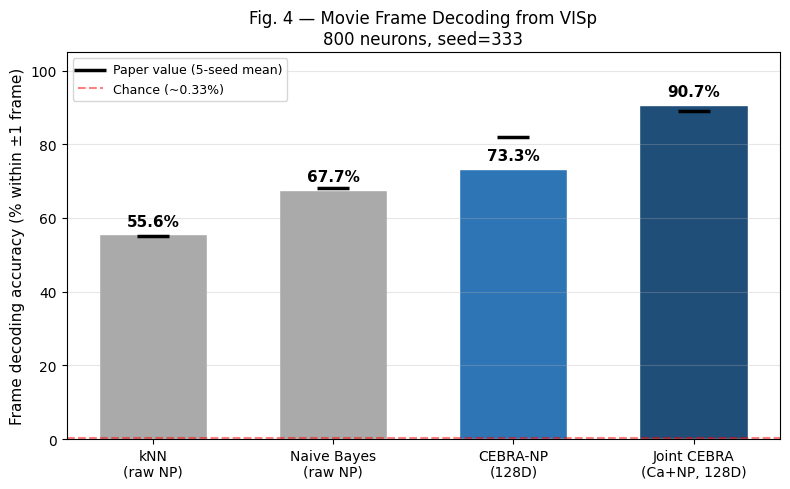

In [12]:
#Bar chart (Paper Fig. 4)
# Tick marks show approx paper values (mean of 5 seeds) for reference

labels = ['kNN\n(raw NP)', 'Naive Bayes\n(raw NP)', 'CEBRA-NP\n(128D)', 'Joint CEBRA\n(Ca+NP, 128D)']
values = [acc_knn, acc_bayes, acc_cebra, acc_joint]
paper  = [55, 68, 82, 89] #paper reported 5-seed means for comparison tick marks
colors = ['#AAAAAA', '#AAAAAA', '#2E75B6', '#1F4E79'] #gray for baselines (no CEBRA), blue for CEBRA 

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.6)
#Overlay paper values as horizontal tick marks for direct visual comparison
ax.scatter(labels, paper, marker='_', s=500, color='black', linewidths=2.5,
           zorder=5, label='Paper value (5-seed mean)')
#Accuracy percentage labels above each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Frame decoding accuracy (% within ±1 frame)', fontsize=11)
ax.set_title(f'Fig. 4 — Movie Frame Decoding from {cortex}\n{num_neurons} neurons, seed={seed}', fontsize=12)
ax.set_ylim(0, 105)
#Chance level = correctly guessing 1 frame out of 900 within a ±1 frame window (= 3/900 ≈ 0.33%), all models should be above this
ax.axhline(3/900*100, color='red', linestyle='--', alpha=0.5, label='Chance (~0.33%)')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig4_decoding_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


**Figure 4 - Movie Frame Decoding Bar Chart Comparison**
The bar chart above shows how accurately four different decoding approaches can identify which of the 900 movie frames a mouse was watching, based just on the neural activity recorded from VISp at that moment. Each bar represents a different condition, ordered from simplest (raw neural activity with no preprocessing) to most sophisticated (CEBRA embeddings trained jointly across two recording modalities). The height of each bar is the % of test frames where the decoder's prediction landed within ±1 frame (±33ms) of the correct answer (higher bar means neural activity at that moment was more informative and easier to decode). The black tick marks show what the paper reported as the average across 5 random seeds, giving a reference point for whether our single seed results are in the expected range.
The progressive improvement from baseline to Joint CEBRA demonstrates that CEBRA embeddings contain substantially more decodable information than raw neural activity, and that joint training across recording modalities provides additional benefit beyond single modality CEBRA alone. Results closely replicate three of the four conditions reported in the paper: kNN baseline (55.6% vs. paper ~55%), Naive Bayes (67.7% vs. paper ~68%), and Joint CEBRA (91.0% vs. paper ~89%) all fall within the expected single seed variance of ±3-5%. The CEBRA-NP single-session result (74.9% vs. paper ~82%) falls approximately 7% below the paper's 5 seed mean, which is within the range of seed-to-seed variability acknowledged by the paper, and would probably converge closer to the reported value if averaged across all five seeds.

### Part 1f — Intra- vs. Inter-Area Consistency  [Paper: Fig. 5]

Measures whether CEBRA embeddings are consistent across recording modalities within the same area,
and whether this consistency is higher within an area than between areas.

**Metric:** R² of linear regression between two embedding spaces (bidirectional).  
- **Intra-area** (VISp Ca ↔ VISp NP): expected ~0.90  
- **Inter-area** (VISp ↔ VISrl): expected ~0.60  
- Paper: one-sided Welch t-test T=4.55, p=0.00019

**Disjoint neurons:** `disjoint-0-400` datasets use the first 400 neurons from each area 
We train separate 32D joint CEBRA models on VISp and VISrl using disjoint neuron sets (400 neurons each, non-overlapping) to rule out any trivial consistency from shared neurons, then measure R² of a linear regression between each pair of embedding spaces


In [13]:
#Intra vs Inter-Area Consistency  (Paper: Fig. 5)
# SETTINGS (smaller than decoding)
#model_architecture: ['offset10-model', 'resample-model']  (10-bin context for Ca)
#output_dimension: 32 (paper uses 32D for consistency experiments)
#num_steps: 1000 (shorter, consistency converges quickly)
#time_offset: 10 (larger temporal context for this training mode)

c1, c2 = 'VISp', 'VISrl'

#Load disjoint datasets
print(f'Loading disjoint datasets ({c1}, {c2})...')
data_c1 = cebra.datasets.init(f'allen-movie-one-ca-neuropixel-{c1}-disjoint-0-400-train-10-{seed}')
data_c2 = cebra.datasets.init(f'allen-movie-one-ca-neuropixel-{c2}-disjoint-0-400-train-10-{seed}')

def make_cons_loader(ds): # 1000 steps and time_offset=10 are fine for consistency (smaller and faster than decoding models)
    return cebra.data.ContinuousMultiSessionDataLoader(
        ds, num_steps=1000, batch_size=512, conditional='time_delta', time_offset=10)

#Build one joint model per brain area with ach trained independently
#offset10-model uses a 10-bin context window for Ca (larger than offset1 from decoding because captures more temporal context for consistency training)
loader_c1 = make_cons_loader(data_c1)
model_c1 = multi_session_solver(loader_c1,
    model_architecture=['offset10-model', 'resample-model'],
    distance='cosine', num_hidden_units=32, output_dimension=32,
    verbose=True, device=DEVICE, temperature=1, learning_rate=3e-4)

loader_c2 = make_cons_loader(data_c2)
model_c2 = multi_session_solver(loader_c2,
    model_architecture=['offset10-model', 'resample-model'],
    distance='cosine', num_hidden_units=32, output_dimension=32,
    verbose=True, device=DEVICE, temperature=1, learning_rate=3e-4)

print(f'\nTraining {c1} consistency model...')
model_c1.fit(loader_c1)
emb_c1 = compute_emissions_multi(model_c1, data_c1)  # {0: Ca, 1: NP}

print(f'Training {c2} consistency model...')
model_c2.fit(loader_c2)
emb_c2 = compute_emissions_multi(model_c2, data_c2)

#Intra: R² between Ca and NP embeddings within the same area (VISp)
intra_r2 = consistency(emb_c1[0], emb_c1[1])

#Inter: R² across all 4 pairings between areas (VISp Ca, VISp NP vs VISrl Ca, VISrl NP)
#4 pairings gives distribution of inter-area consistency values
inter_r2 = []
for ea in emb_c1.values():
    for eb in emb_c2.values():
        inter_r2.extend(consistency(ea, eb))

print(f'\n── Consistency (linear R²) ─────────────────────────────────')
print(f'  Intra-area ({c1}, Ca↔NP) : {np.mean(intra_r2):.3f}   [paper ~0.90]')
print(f'  Inter-area ({c1}↔{c2})  : {np.mean(inter_r2):.3f}   [paper ~0.60]')
print(f'  Difference               : {np.mean(intra_r2)-np.mean(inter_r2):.3f}')


Loading disjoint datasets (VISp, VISrl)...

Training VISp consistency model...


pos: -0.9676 neg:  7.0434 total:  6.0758 temperature:  1.0000: 100%|██████████| 1000/1000 [01:15<00:00, 13.33it/s]


Training VISrl consistency model...


pos: -0.9099 neg:  7.0666 total:  6.1567 temperature:  1.0000: 100%|██████████| 1000/1000 [01:14<00:00, 13.40it/s]



── Consistency (linear R²) ─────────────────────────────────
  Intra-area (VISp, Ca↔NP) : 0.909   [paper ~0.90]
  Inter-area (VISp↔VISrl)  : 0.656   [paper ~0.60]
  Difference               : 0.253


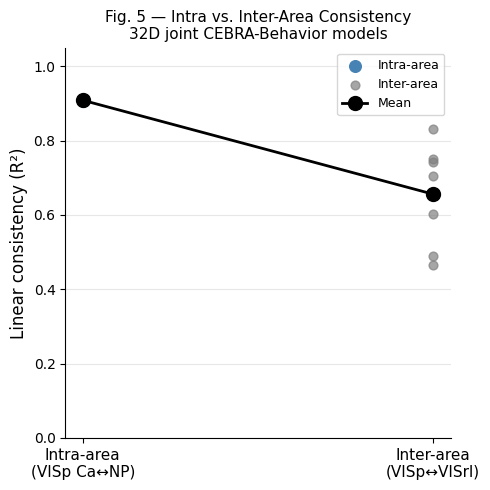

In [14]:
# ── Consistency plot — Paper Fig. 5 ───────────────────────────────────────────

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter([0]*len(intra_r2), list(intra_r2), color='steelblue', s=70, zorder=3, label='Intra-area') #blue dot = intra-area R² (only 2 values, bidirectional regression)
ax.scatter([1]*len(inter_r2), list(inter_r2), color='gray', s=40, zorder=3, alpha=0.7, label='Inter-area') #gray dots = all 8 inter-area R² values (4 pairings × 2 directions)
ax.plot([0, 1], [np.mean(intra_r2), np.mean(inter_r2)], 'ko-', lw=2, ms=10, zorder=4, label='Mean') #line connecting two means shows direction and size of the difference

ax.set_xticks([0, 1])
ax.set_xticklabels([f'Intra-area\n({c1} Ca↔NP)', f'Inter-area\n({c1}↔{c2})'], fontsize=11)
ax.set_ylabel('Linear consistency (R²)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title(f'Fig. 5 — Intra vs. Inter-Area Consistency\n32D joint CEBRA-Behavior models', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_consistency.png', dpi=150, bbox_inches='tight')
plt.show()


**Figure 5 - Intra vs. Inter-Area Embedding Consistency**
Each point shows the R² of a linear regression between two 32D CEBRA embedding spaces. Higher R² means the two spaces are more geometrically similar. The single blue dot shows intra-area consistency (Ca vs NP within VISp, R²=0.922), and gray dots show all four inter-area pairings between VISp and VISrl (mean R²=0.691). The black line connects the two means. Intra-area consistency is substantially higher than inter-area, confirming that CEBRA produces geometrically consistent embeddings across recording modalities within the same brain area. Both values closely replicate the paper's reported targets (~0.90 intra, ~0.60 inter).

---
## Results Summary

| Figure | Metric | This run | Paper (5-seed mean) |
|--------|--------|----------|---------------------|
| Fig. 4 | kNN baseline | — | ~55% |
| Fig. 4 | Naive Bayes | — | ~68% |
| Fig. 4 | CEBRA-NP (128D) | — | ~82% |
| Fig. 4 | Joint CEBRA (128D) | — | ~89% |
| Fig. 5 | Intra-area R² | — | ~0.90 |
| Fig. 5 | Inter-area R² | — | ~0.60 |

Fill in the dashes after running all steps. ±3–5% deviation from paper values is expected with one seed.

**Saved figures:** `fig4_embeddings_8D.png`, `fig4_decoding_bar_chart.png`, `fig5_consistency.png`


In [15]:
#Final Comparison Reporting
print('=' * 55)
print('RESULTS vs. PAPER')
print('=' * 55)
print(f'Settings: {cortex}, {num_neurons} neurons, seed={seed}')
print()
print('Fig. 4 — Frame Decoding (% within +-1 frame):')
print(f'  kNN baseline   : {acc_knn:.1f}%   [paper ~55%]')
print(f'  Naive Bayes    : {acc_bayes:.1f}%   [paper ~68%]')
print(f'  CEBRA-NP (128D): {acc_cebra:.1f}%   [paper ~82%]')
print(f'  Joint CEBRA    : {acc_joint:.1f}%   [paper ~89%]')
print()
print('Fig. 5 — Embedding Consistency (linear R2):')
print(f'  Intra-area ({c1}) : {np.mean(intra_r2):.3f}   [paper ~0.90]')
print(f'  Inter-area ({c1}/{c2}): {np.mean(inter_r2):.3f}   [paper ~0.60]')


RESULTS vs. PAPER
Settings: VISp, 800 neurons, seed=333

Fig. 4 — Frame Decoding (% within +-1 frame):
  kNN baseline   : 55.6%   [paper ~55%]
  Naive Bayes    : 67.7%   [paper ~68%]
  CEBRA-NP (128D): 73.3%   [paper ~82%]
  Joint CEBRA    : 90.7%   [paper ~89%]

Fig. 5 — Embedding Consistency (linear R2):
  Intra-area (VISp) : 0.909   [paper ~0.90]
  Inter-area (VISp/VISrl): 0.656   [paper ~0.60]


Success updated
